# Seaborn을 활용한 Sleep_health Data 시각화 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv",
                keep_default_na=False)

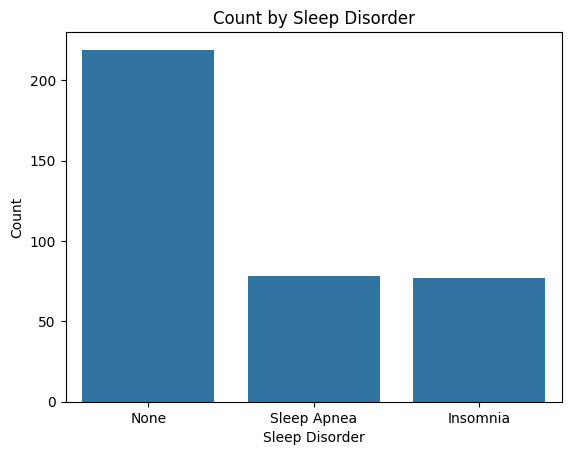

In [4]:
#수면 장애별 인원수
sns.countplot(data=df, x="Sleep Disorder")

plt.title("Count by Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.show()

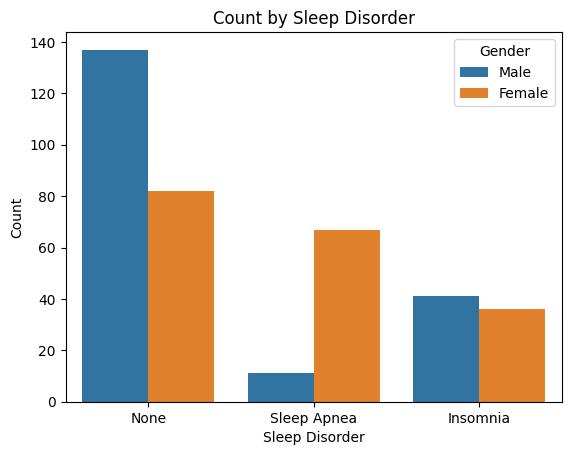

In [5]:
#수면 장애별 남녀 수
sns.countplot(data=df, x="Sleep Disorder", hue="Gender")
plt.title("Count by Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Sleep Duration', ylabel='Count'>

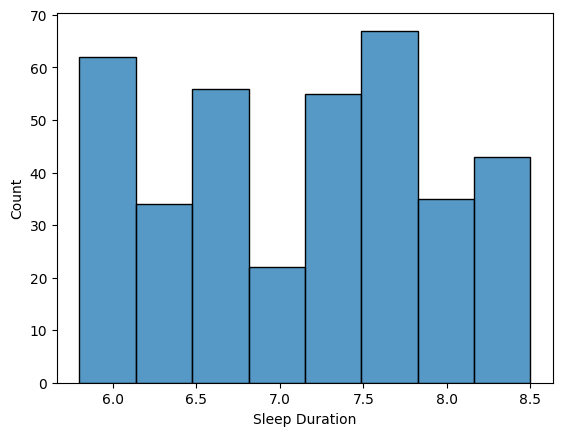

In [6]:
#수면시간별 인원 수
sns.histplot(data=df, x="Sleep Duration" , bins=8 , edgecolor ="black")

In [7]:
df["Age"].describe()

count    374.000000
mean      42.184492
std        8.673133
min       27.000000
25%       35.250000
50%       43.000000
75%       50.000000
max       59.000000
Name: Age, dtype: float64

Text(0.5, 0, 'Age')

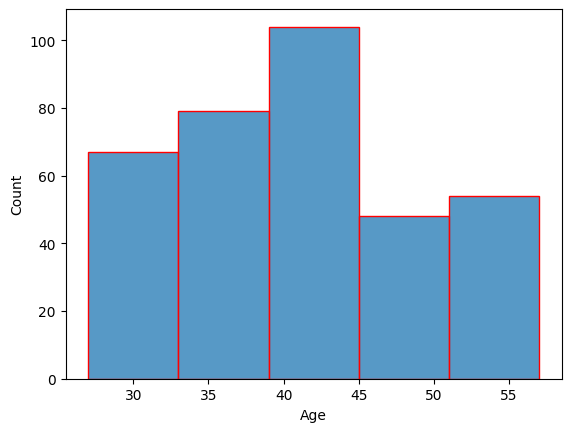

In [8]:
#나이별 인구수
sns.histplot(data=df,x="Age",bins=range(27,60,6), edgecolor="Red")
plt.xlabel("Age")

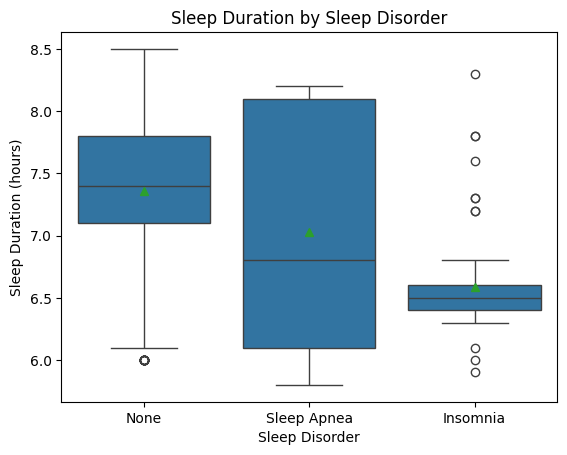

In [9]:
#수면 장애별 수면 시간 박스플롯 /* showmeans=True
sns.boxplot(data=df, x="Sleep Disorder", y="Sleep Duration",showmeans=True)

plt.title("Sleep Duration by Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Sleep Duration (hours)")
plt.show()

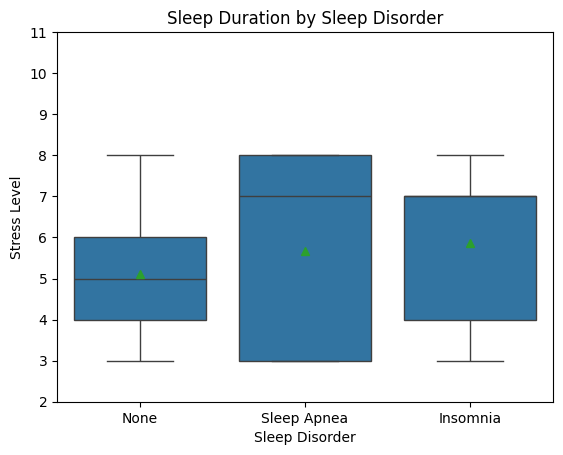

In [10]:
#수면 장애별 수면 시간 박스플롯 /* showmeans=True
sns.boxplot(data=df, x="Sleep Disorder", y="Stress Level",showmeans=True)

plt.title("Sleep Duration by Sleep Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Stress Level")
plt.ylim(2,11)
plt.show()

In [11]:
df["Age"].describe()

count    374.000000
mean      42.184492
std        8.673133
min       27.000000
25%       35.250000
50%       43.000000
75%       50.000000
max       59.000000
Name: Age, dtype: float64

In [12]:
Age_20s = df[(df["Age"] >=27) & (df["Age"] < 30)]
Age_30s = df[(df["Age"] >=30) & (df["Age"] < 40)]
Age_40s = df[(df["Age"] >=40) & (df["Age"] < 50)]
Age_50s = df[(df["Age"] >=50) & (df["Age"] < 60)]

In [13]:
Age_data = pd.concat([
    Age_20s.assign(Age_group = "20s"),
    Age_30s.assign(Age_group = "30s"),
    Age_40s.assign(Age_group = "40s"),
    Age_50s.assign(Age_group = "50s")
]
)
Age_data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age_group
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,20s
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,20s
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,20s
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,20s
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,20s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,50s
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,50s
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,50s
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,50s


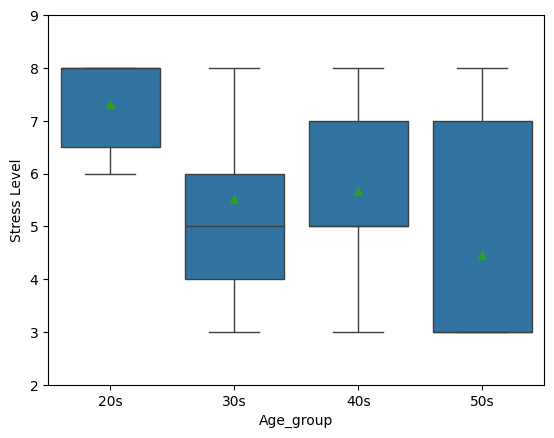

In [14]:
#나이대별 스트레스 레벨 Boxplot
sns.boxplot(data=Age_data , x = "Age_group" , y ="Stress Level",showmeans = True)
plt.ylim(2,9)
plt.show()

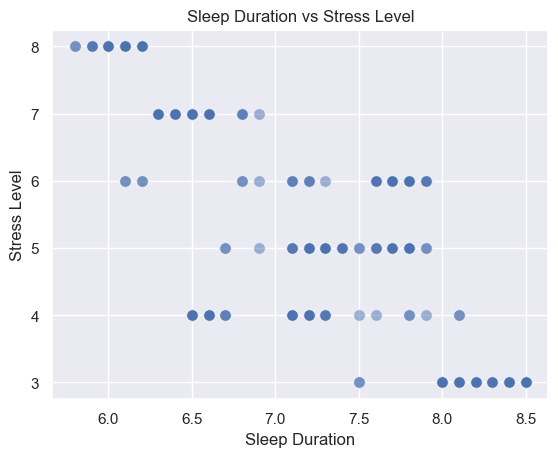

In [30]:
#수면시간과 스트레스 레벨 산점도
sns.set_theme(style="darkgrid")
sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Stress Level",
    s=70,
    alpha=0.5
)

plt.title("Sleep Duration vs Stress Level")
plt.show()

In [16]:
from scipy.stats import pearsonr
r , p_value = pearsonr(df["Stress Level"] , df["Sleep Duration"])
print(f"상관계수:{r},\np_value:{p_value}")

상관계수:-0.8110230278940431,
p_value:1.2378076181537591e-88


In [17]:
#두 변수는 음의 상관관계를 가짐

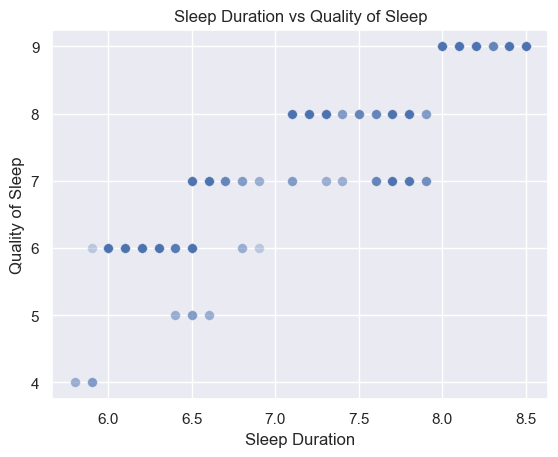

In [18]:
sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Quality of Sleep",
    s=50,
    alpha=0.3
)

plt.title("Sleep Duration vs Quality of Sleep")
plt.show()

In [19]:
r , p_value = pearsonr(df["Stress Level"] , df["Sleep Duration"])
print(f"상관계수:{r},\np_value:{p_value}")

상관계수:-0.8110230278940431,
p_value:1.2378076181537591e-88


In [20]:
#두 변수는 양의 상관관계를 가짐

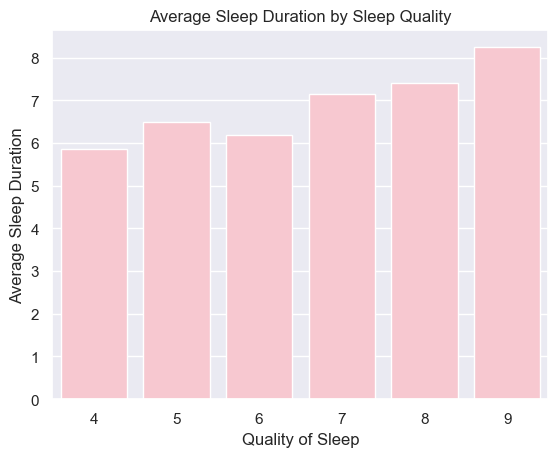

In [21]:
sns.barplot(
    data=df,
    x="Quality of Sleep",
    y="Sleep Duration",
    color="pink",
    errorbar=None
)

plt.xlabel("Quality of Sleep")
plt.ylabel("Average Sleep Duration")
plt.title("Average Sleep Duration by Sleep Quality")
plt.show()

<Axes: xlabel='BMI Category', ylabel='Daily Steps'>

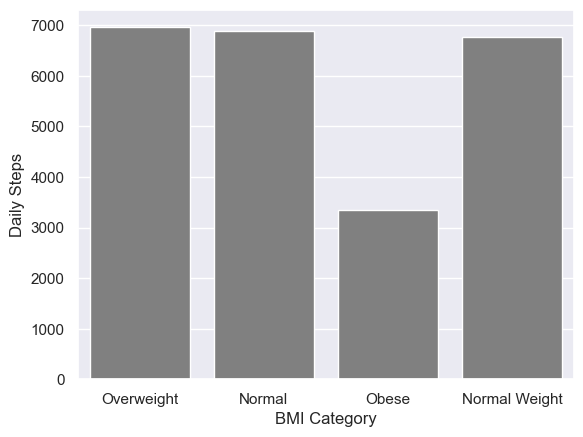

In [22]:
sns.barplot(data=df, 
            x="BMI Category", 
            y="Daily Steps",
            color="grey",
            errorbar=None)

In [23]:
corr = (
    df.drop(columns=["Person ID"])
    .select_dtypes(include="number")
    .corr()
)

In [24]:
corr

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Age,1.000000,0.344709,0.473734,0.178993,-0.422344,-0.225606,0.057973
Sleep Duration,0.344709,1.000000,0.883213,0.212360,-0.811023,-0.516455,-0.039533
Quality of Sleep,0.473734,0.883213,1.000000,0.192896,-0.898752,-0.659865,0.016791
Physical Activity Level,0.178993,0.212360,0.192896,1.000000,-0.034134,0.136971,0.772723
Stress Level,-0.422344,-0.811023,-0.898752,-0.034134,1.000000,0.670026,0.186829
Heart Rate,-0.225606,-0.516455,-0.659865,0.136971,0.670026,1.000000,-0.030309
Daily Steps,0.057973,-0.039533,0.016791,0.772723,0.186829,-0.030309,1.000000


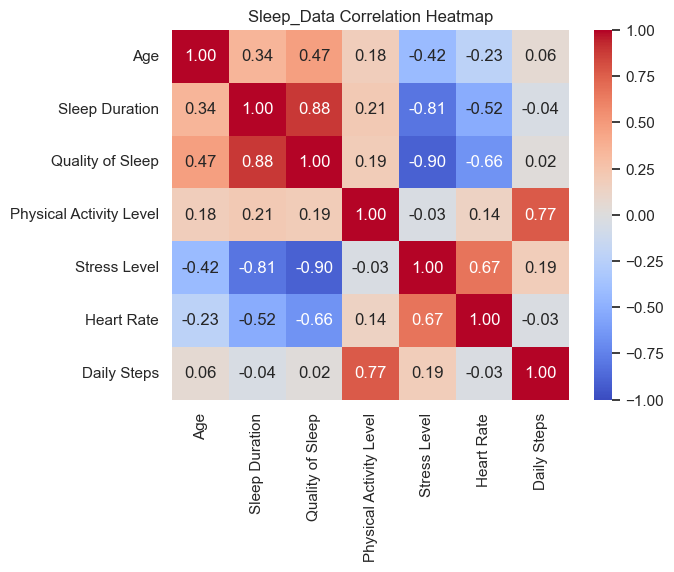

In [25]:
sns.heatmap(
    corr,
    annot=True, # 상관계수 숫자 표시
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, 
    vmax=1 # 색상 범위를 상관계수의 최솟값 -1부터 최댓값 1로 고정
)

plt.title("Sleep_Data Correlation Heatmap")
plt.show()

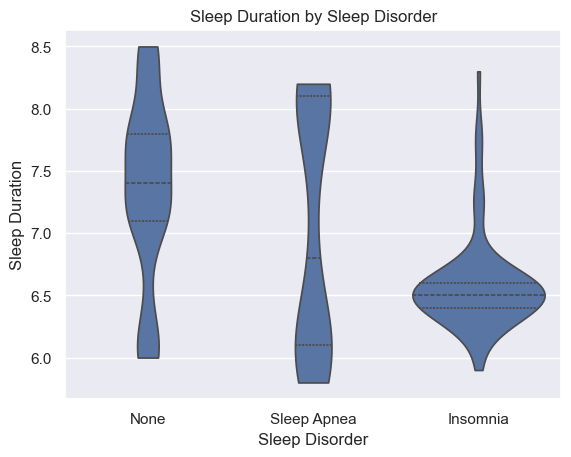

In [26]:
sns.violinplot(
    data=df,
    x="Sleep Disorder",
    y="Sleep Duration",
    inner="quart", #Q1, Q3, 중앙값 선으로 표시
    cut=0
)

plt.title("Sleep Duration by Sleep Disorder")
plt.show()

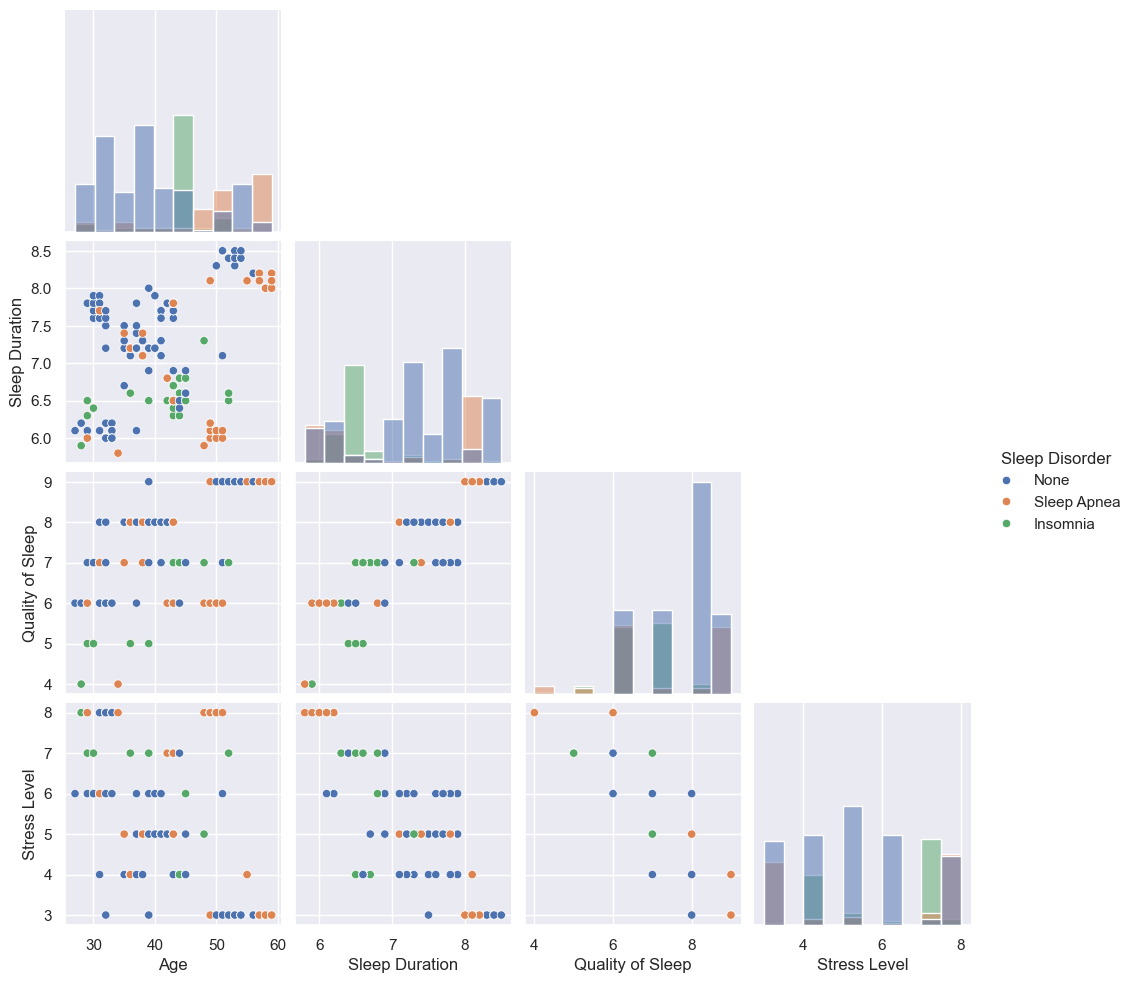

In [28]:
sns.pairplot(
    data=df,
    vars=["Age", "Sleep Duration", "Quality of Sleep", "Stress Level"],
    hue="Sleep Disorder",
    diag_kind="hist",
    corner=True
)

plt.show()

C:\Users\방재우\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\방재우\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 18.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\방재우\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\방재우\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 11.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\방재우\AppData\Roaming\Python\P

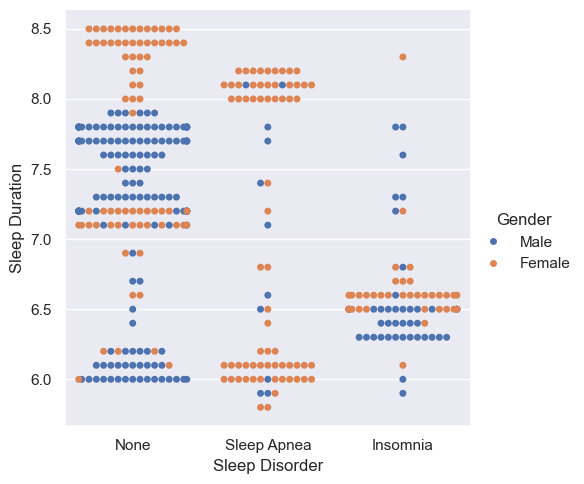

In [52]:
sns.catplot(data=df, x = "Sleep Disorder", 
            y = "Sleep Duration", 
            kind= "swarm",
            hue= "Gender",
            )